In [30]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Erdös-Rényi model

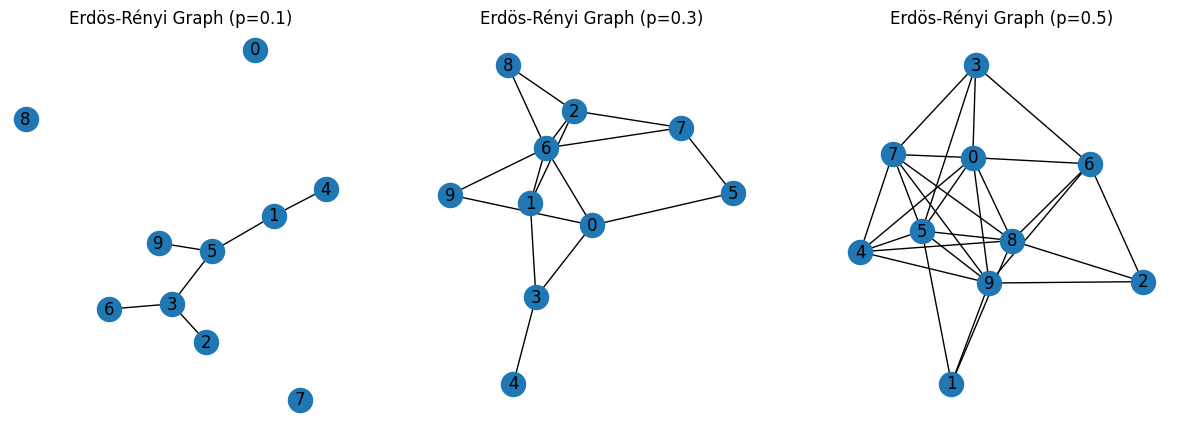

In [21]:
# generate 3 random graphs using the Erdös-Rényi model and plot them in a grid with 1 row and 3 columns
# Include the p value in the title of each subplot
p_values = [0.1, 0.3, 0.5]
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, p in enumerate(p_values):
    G = nx.erdos_renyi_graph(10, p)
    nx.draw(G, ax=axs[i], with_labels=True)
    axs[i].set_title(f"Erdös-Rényi Graph (p={p})")
plt.show()

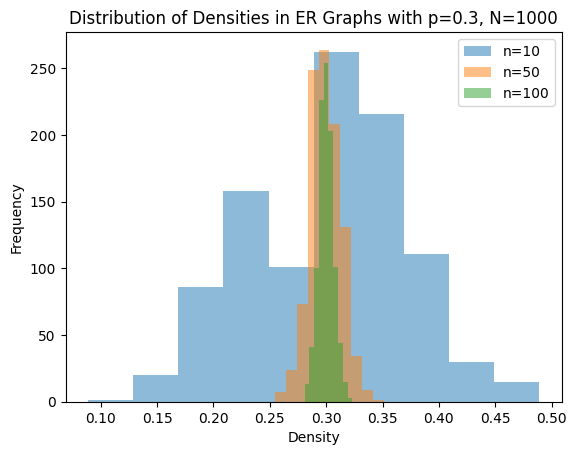

In [13]:
# use nx.erdos_renyi_graph(n, p) to generate 100 random graphs with 10 nodes and edge probability 0.3
n = 10 # number of nodes
p = 0.3 # probability of edge creation
N = 1000 # number of graphs to generate
def density_dist(n, p, N):
    graphs = [nx.erdos_renyi_graph(n, p) for _ in range(N)]
    densities = [nx.density(g) for g in graphs]
    return densities

# for p = 0.3, N=1000, generate density distribution for n in [10, 50, 100]
# then plot the histograms
n_values = [10, 50, 100]
p = 0.3
N = 1000 

for n in n_values:
    densities = density_dist(n, p, N)
    plt.hist(densities, bins=10, alpha=0.5, label=f'n={n}')
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Distribution of Densities in ER Graphs with p=0.3, N=1000')
plt.legend()
plt.show()

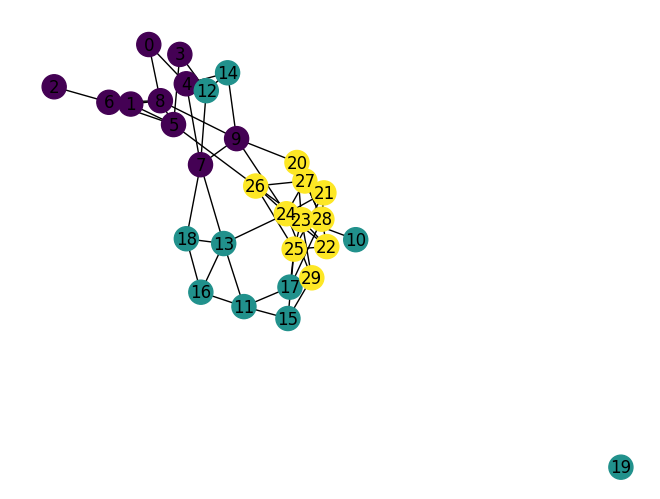

In [28]:
sizes = [10, 10, 10]
probs = [[0.4, 0.05, 0.02], [0.05, 0.4, 0.07], [0.02, 0.07, 0.40]]
g = nx.stochastic_block_model(sizes, probs, seed=0)
# color each node by its block
colors = []
for node in g.nodes():
    for block_index, size in enumerate(sizes):
        if node < sum(sizes[:block_index + 1]):
            colors.append(block_index)
            break
nx.draw(g, node_color=colors, with_labels=True)
plt.show()

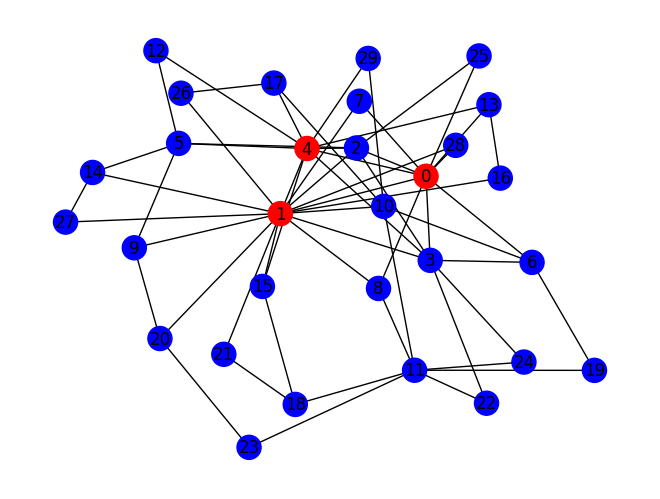

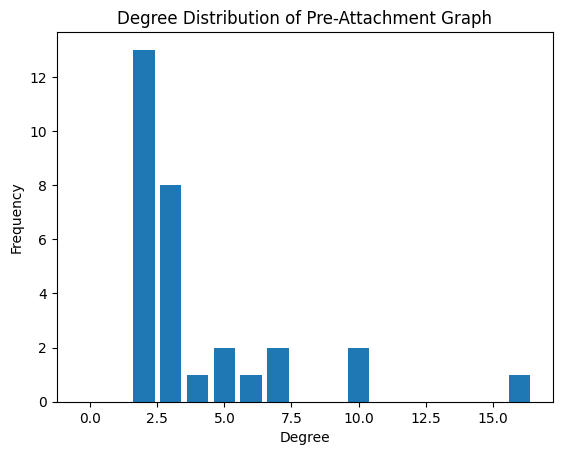

In [34]:
def pre_attachment_graph(m0, n, m):
    G = nx.complete_graph(m0)
    for new_node in range(m0, n):
        targets = set()
        while len(targets) < m:
            potential_target = np.random.choice(G.nodes())
            degree_sum = sum(dict(G.degree()).values())
            prob = G.degree(potential_target) / degree_sum
            if np.random.uniform() < prob:
                targets.add(potential_target)
        G.add_node(new_node)
        for target in targets:
            G.add_edge(new_node, target)
    return G

#plot graph, color nodes with degree outside one standard deviation from the mean in red, others in blue
G = pre_attachment_graph(m0=5, n=30, m=2)
degrees = np.array([d for n, d in G.degree()])
mean_degree = degrees.mean()
std_degree = degrees.std()
colors = ['red' if (d < mean_degree - std_degree or d > mean_degree + std_degree) else 'blue' for d in degrees]
nx.draw(G, node_color=colors, with_labels=True)
plt.show()

# plot the degree distribution of the generated graph
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins=range(max(degrees)+2), align='left', rwidth=0.8)
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution of Pre-Attachment Graph')
plt.show()